In [1]:
import os
import joblib
import pandas as pd
from string import punctuation
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

In [2]:
df = pd.read_csv("Symptom2Disease.csv")
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [3]:
#preprocess function
def tag_to_wordnet(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(sentence):
    # tokenizations
    tokens = word_tokenize(sentence)
    # cleaning
    cleaned_tokens = [ token.lower() for token in tokens if token.lower() not in stopwords.words('english') and token.lower() not in punctuation]
    # pos tag
    tagged_tokens = pos_tag(cleaned_tokens)
    # lemma
    lemmatized_tokens = [

        WordNetLemmatizer().lemmatize(
            token,
            tag_to_wordnet(tag)
        )
        for token, tag in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

#preprocess text
df['clean_text'] = df['text'].apply(preprocess)

In [4]:
#split data
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [5]:
#TF-IDF Feature extrac
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

os.makedirs("models", exist_ok=True)
joblib.dump(tfidf, "models/tfidf_vectorizer.joblib", compress=True)

['models/tfidf_vectorizer.joblib']

In [6]:
#model
model = MultinomialNB()
model.fit(X_train_tfidf,y_train)

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/tfidf_model.joblib", compress=True)

['models/tfidf_model.joblib']

In [7]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
 )

metrics_df = pd.DataFrame([
    {
        "metric": "accuracy",
        "value": accuracy
    },
    {
        "metric": "weighted_precision",
        "value": weighted_precision
    },
    {
        "metric": "weighted_recall",
        "value": weighted_recall
    },
    {
        "metric": "weighted_f1",
        "value": weighted_f1
    }
])

print(metrics_df)

Accuracy : 0.9375

Classification Report

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.92      1.00      0.96        12
                    Common Cold       1.00      1.00      1.00        12
                         Dengue       0.91      0.83      0.87        12
          Dimorphic Hemorrhoids       0.78      1.00      0.88         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        11
                       Jaundice       1.00      1.00      1.00        11
        

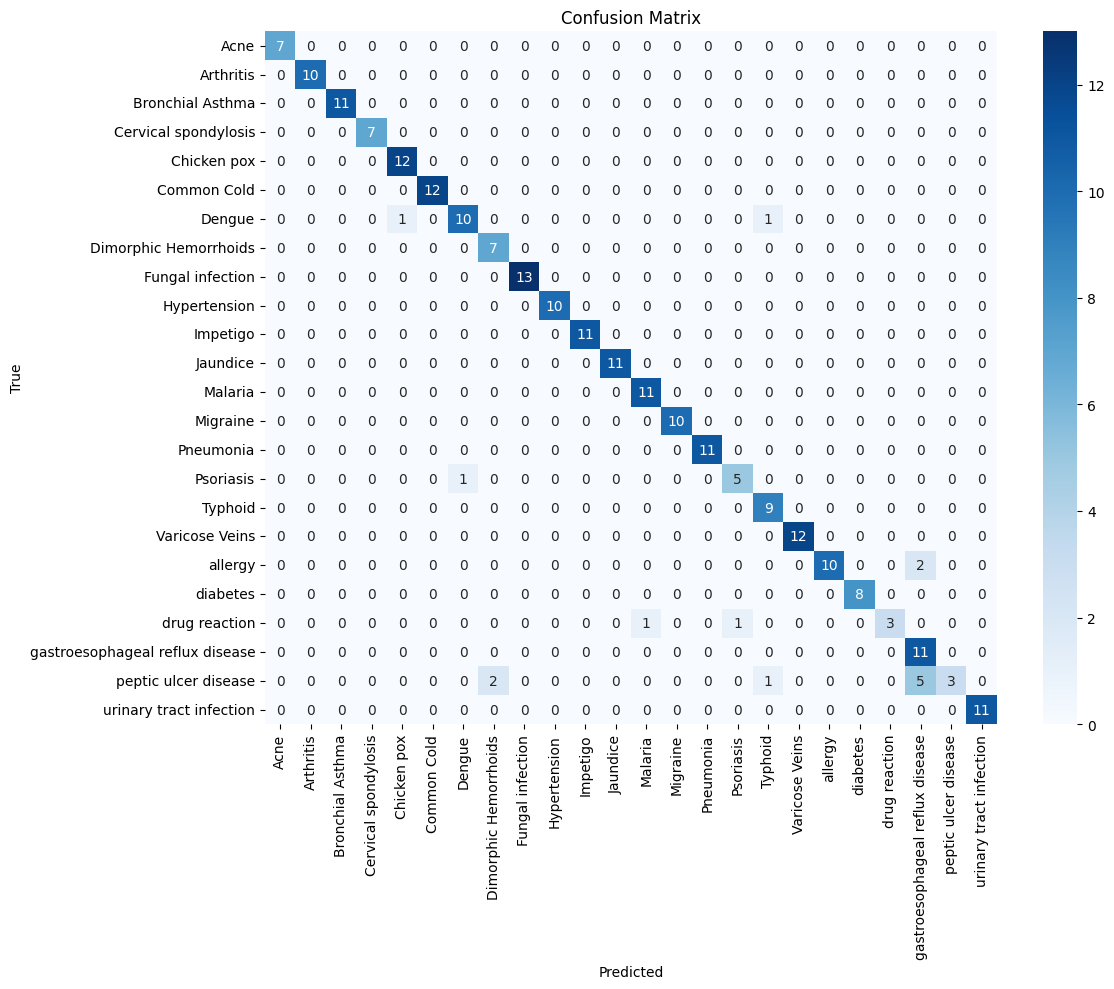

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
 )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()